
* # of characters
* how they affect ratings
* calculate how long a character has been alive / # of episode appearances, repeat characters vs. new characters effect on ratings


In [ ]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

api_key = '2c8582201c384f391717ec9c72e88fa7'

# made 7 empty lists to loop through / add onto in the for loop below for each episode in seasons 1-8
names = []
vote_averages = []
vote_counts = []
ids = []
episode_numbers = []
season_numbers =[]
ep_ids = []

#start episode ID at 1
ep_id = 1

for season in range(1,9):

# Get all episodes for a season
  r = requests.get(f'https://api.themoviedb.org/3/tv/60625/season/{season}?api_key={api_key}')
  data = r.json()

  # Each episode has: name, ep_id, episode_number, season_number, vote_average, vote_count
  # For each episode,
  for ep in data['episodes']:
      # made uppercase and removed the commas and colons so that the episode titles correlate when merging the TMDB and Rick and Morty api datasets
      names.append(ep['name'].upper().replace(',', '').replace(':', ''))
      ids.append(ep['id'])
      episode_numbers.append(ep['episode_number'])
      season_numbers.append(ep['season_number'])
      vote_averages.append(ep['vote_average'])
      vote_counts.append(ep['vote_count'])
      # created my own episode ID in order to merge it with the avg_age list
      ep_ids.append(ep_id)
      ep_id = ep_id + 1

# Combining all lists into a DF
ratings = pd.DataFrame({'Episode': names,
                        'ID': ep_ids,
                        'Episode Number': episode_numbers,
                        'Season Number': season_numbers,
                        'Rating': vote_averages,
                        'Number of Voters': vote_counts})
# filtered the data for only seasons 1-5 (to match the data from the rick and morty api)
# also excluded pilot episode bc it had an unbalanced # of voters compared to the rest of the episodes
ratings = ratings[(ratings['Season Number'] <= 5) & ~((ratings['Season Number'] == 1) & (ratings['Episode Number'] == 1))]

**Tests for TMDB API**

In [ ]:
# Displaying all of the information from a specific episode (in this case episode 1)
print(json.dumps(data['episodes'][0], indent=2))

# Showing all the data I gathered from the TMDB API
display(ratings)

# Showing the data for a specific episode (in this case episode 5)
display(ratings[ratings['ID'] == 5])

# Checking the size / episode count of the ratings DF
print(len(ratings))

{
  "air_date": "2025-05-25",
  "episode_number": 1,
  "episode_type": "standard",
  "id": 6085790,
  "name": "Summer of All Fears",
  "overview": "Rick left the kids in a matrix. Not chill, broh.",
  "production_code": "",
  "runtime": 24,
  "season_number": 8,
  "show_id": 60625,
  "still_path": "/t7arWMclhZ8Kub48ymLvbDUN5Qg.jpg",
  "vote_average": 8.5,
  "vote_count": 37,
  "crew": [
    {
      "job": "Storyboard Artist",
      "department": "Art",
      "credit_id": "632bd859ecbde9007b22a720",
      "adult": false,
      "gender": 2,
      "id": 3710672,
      "known_for_department": "Art",
      "name": "Dan O'Connor",
      "original_name": "Dan O'Connor",
      "popularity": 0.1723,
      "profile_path": null
    },
    {
      "job": "Storyboard Artist",
      "department": "Art",
      "credit_id": "632bd7cc2dffd8007f229b97",
      "adult": false,
      "gender": 0,
      "id": 1447458,
      "known_for_department": "Writing",
      "name": "Rufino Camacho",
      "original_n

,Episode,ID,Episode Number,Season Number,Rating,Number of Voters
1,LAWNMOWER DOG,2,2,1,8.000,149
2,ANATOMY PARK,3,3,1,7.900,133
3,M. NIGHT SHAYM-ALIENS!,4,4,1,7.900,137
4,MEESEEKS AND DESTROY,5,5,1,8.300,136
5,RICK POTION #9,6,6,1,8.400,128
6,RAISING GAZORPAZORP,7,7,1,7.700,131
7,RIXTY MINUTES,8,8,1,8.000,128
8,SOMETHING RICKED THIS WAY COMES,9,9,1,7.800,127
9,CLOSE RICK-COUNTERS OF THE RICK KIND,10,10,1,8.700,133
10,RICKSY BUSINESS,11,11,1,7.700,130


,Episode,ID,Episode Number,Season Number,Rating,Number of Voters
4,MEESEEKS AND DESTROY,5,5,1,8.3,136


50


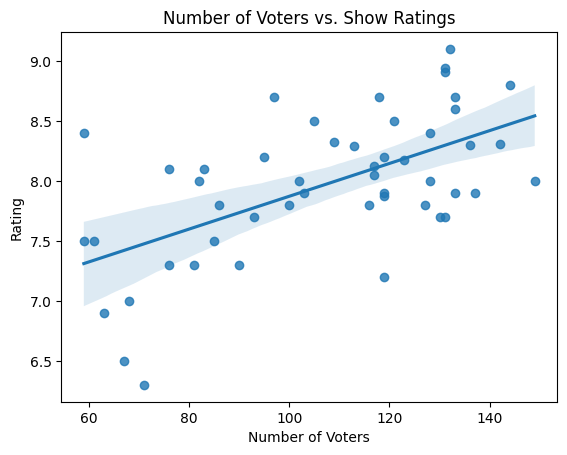

In [ ]:
sns.regplot(data=ratings, x='Number of Voters', y='Rating')
plt.title('Number of Voters vs. Show Ratings');
# Small sample size but looks like more voters = higher rating
# Pilot episode is excluded b/c it had an anomolous amount of voters
# Made this graph after the graphs below

In [ ]:
import time

episodes = []
characters = []
url = 'https://rickandmortyapi.com/api/episode'

# Starts with the URL from the rick and morty api
while url:
  # Gets the response from the URL
  response = requests.get(url)
  # If there's an error, then the loop stops
  if response.status_code != 200:
    print(f"Error: {response.status_code}")
    break
  data = response.json()
  # This moves all the values from data[results] to episodes list
  episodes.extend(data['results'])
  # The response from the api sometimes contains multiple pages, and if it does then "next" contains the url to the next page
  # If not, it is null and will stop the loop
  url = data['info']['next']
  # API has rate limits, so waiting for 1 second between requests
  time.sleep(1)

# Making a new DF focused on number of characters per episode
num_char = pd.DataFrame(episodes)
# Making new column in existing DF, setting it equal to number of charcters per episode
num_char['char_count'] = (num_char['characters'].str.len())
# Making a new column and updating episode name by capitalizing and removing commas and colons to get the rick and morty data ready to merge with the TMDB data
num_char['merge_name'] = num_char['name'].str.upper().str.replace(',', '').str.replace(':', '')
# Making a new column, extracting the season number from the episode column (the second and third character from the episode column)
num_char['season'] = num_char['episode'].str[1:3].astype(int)

num_char = num_char[['merge_name', 'name', 'char_count', 'air_date', 'episode', 'season']]
display(num_char)
print(len(num_char))

,merge_name,name,char_count,air_date,episode,season
0,PILOT,Pilot,19,"December 2, 2013",S01E01,1
1,LAWNMOWER DOG,Lawnmower Dog,19,"December 9, 2013",S01E02,1
2,ANATOMY PARK,Anatomy Park,24,"December 16, 2013",S01E03,1
3,M. NIGHT SHAYM-ALIENS!,M. Night Shaym-Aliens!,13,"January 13, 2014",S01E04,1
4,MEESEEKS AND DESTROY,Meeseeks and Destroy,20,"January 20, 2014",S01E05,1
5,RICK POTION #9,Rick Potion #9,24,"January 27, 2014",S01E06,1
6,RAISING GAZORPAZORP,Raising Gazorpazorp,14,"March 10, 2014",S01E07,1
7,RIXTY MINUTES,Rixty Minutes,57,"March 17, 2014",S01E08,1
8,SOMETHING RICKED THIS WAY COMES,Something Ricked This Way Comes,17,"March 24, 2014",S01E09,1
9,CLOSE RICK-COUNTERS OF THE RICK KIND,Close Rick-counters of the Rick Kind,60,"April 7, 2014",S01E10,1


51


**Tests for Rick and Morty API**


---



In [ ]:
# Displaying all of the information from a specific episode (in this case episode 1)
print(json.dumps(data['results'][0], indent=2))

# Showing all the data I gathered from the Rick and Morty API
display(num_char)

# Showing the data for a specific episode (in this case episode 2)
display(num_char[num_char['episode'] == 'S01E02'])

# Checking the size / episode count of the num_char DF
# Only 51 episodes available from this API (Seasons 1-5)
print(len(num_char))

{
  "id": 41,
  "name": "Star Mort: Rickturn of the Jerri",
  "air_date": "May 31, 2020",
  "episode": "S04E10",
  "characters": [
    "https://rickandmortyapi.com/api/character/1",
    "https://rickandmortyapi.com/api/character/2",
    "https://rickandmortyapi.com/api/character/3",
    "https://rickandmortyapi.com/api/character/4",
    "https://rickandmortyapi.com/api/character/5",
    "https://rickandmortyapi.com/api/character/107",
    "https://rickandmortyapi.com/api/character/344",
    "https://rickandmortyapi.com/api/character/592",
    "https://rickandmortyapi.com/api/character/667",
    "https://rickandmortyapi.com/api/character/668",
    "https://rickandmortyapi.com/api/character/669",
    "https://rickandmortyapi.com/api/character/670",
    "https://rickandmortyapi.com/api/character/671"
  ],
  "url": "https://rickandmortyapi.com/api/episode/41",
  "created": "2020-08-06T05:51:52.079Z"
}


,merge_name,name,char_count,air_date,episode,season
0,PILOT,Pilot,19,"December 2, 2013",S01E01,1
1,LAWNMOWER DOG,Lawnmower Dog,19,"December 9, 2013",S01E02,1
2,ANATOMY PARK,Anatomy Park,24,"December 16, 2013",S01E03,1
3,M. NIGHT SHAYM-ALIENS!,M. Night Shaym-Aliens!,13,"January 13, 2014",S01E04,1
4,MEESEEKS AND DESTROY,Meeseeks and Destroy,20,"January 20, 2014",S01E05,1
5,RICK POTION #9,Rick Potion #9,24,"January 27, 2014",S01E06,1
6,RAISING GAZORPAZORP,Raising Gazorpazorp,14,"March 10, 2014",S01E07,1
7,RIXTY MINUTES,Rixty Minutes,57,"March 17, 2014",S01E08,1
8,SOMETHING RICKED THIS WAY COMES,Something Ricked This Way Comes,17,"March 24, 2014",S01E09,1
9,CLOSE RICK-COUNTERS OF THE RICK KIND,Close Rick-counters of the Rick Kind,60,"April 7, 2014",S01E10,1


,merge_name,name,char_count,air_date,episode,season
1,LAWNMOWER DOG,Lawnmower Dog,19,"December 9, 2013",S01E02,1


51


In [ ]:
# Merging the data from TMDB and Rick and Morty APIs in order to compare character counts and show ratings
# Merge function: left refers to the DF we're starting with (num_char in this case), merging it with ratings, what column in num_char is equal what column in ratings
# Left is from num_char, Right is from ratings
# How: how we want to combine the data (left, right, inner, etc.), left is keeping everything in the left DF, inner is only keeping things that exist in both DFs, right is keeping everything in the right DF
# Using inner to exclude pilot b/c info null from first chart w/ voters
chars_and_ratings = num_char.merge(ratings, left_on='merge_name', right_on='Episode', how='inner')

**Tests for chars_and_ratings**

In [ ]:
# Shows the merged data in one table
display(chars_and_ratings)

# This detects episodes with null info, see if it's a naming / correlation issue among different datasets
# Able to rename by removing puncutation or making all lowercase or uppercase in order to reduce possibility for miscorrelation
chars_and_ratings[chars_and_ratings['Rating'].isna()]

,merge_name,name,char_count,air_date,episode,season,Episode,ID,Episode Number,Season Number,Rating,Number of Voters
0,LAWNMOWER DOG,Lawnmower Dog,19,"December 9, 2013",S01E02,1,LAWNMOWER DOG,2,2,1,8.000,149
1,ANATOMY PARK,Anatomy Park,24,"December 16, 2013",S01E03,1,ANATOMY PARK,3,3,1,7.900,133
2,M. NIGHT SHAYM-ALIENS!,M. Night Shaym-Aliens!,13,"January 13, 2014",S01E04,1,M. NIGHT SHAYM-ALIENS!,4,4,1,7.900,137
3,MEESEEKS AND DESTROY,Meeseeks and Destroy,20,"January 20, 2014",S01E05,1,MEESEEKS AND DESTROY,5,5,1,8.300,136
4,RICK POTION #9,Rick Potion #9,24,"January 27, 2014",S01E06,1,RICK POTION #9,6,6,1,8.400,128
5,RAISING GAZORPAZORP,Raising Gazorpazorp,14,"March 10, 2014",S01E07,1,RAISING GAZORPAZORP,7,7,1,7.700,131
6,RIXTY MINUTES,Rixty Minutes,57,"March 17, 2014",S01E08,1,RIXTY MINUTES,8,8,1,8.000,128
7,SOMETHING RICKED THIS WAY COMES,Something Ricked This Way Comes,17,"March 24, 2014",S01E09,1,SOMETHING RICKED THIS WAY COMES,9,9,1,7.800,127
8,CLOSE RICK-COUNTERS OF THE RICK KIND,Close Rick-counters of the Rick Kind,60,"April 7, 2014",S01E10,1,CLOSE RICK-COUNTERS OF THE RICK KIND,10,10,1,8.700,133
9,RICKSY BUSINESS,Ricksy Business,30,"April 14, 2014",S01E11,1,RICKSY BUSINESS,11,11,1,7.700,130


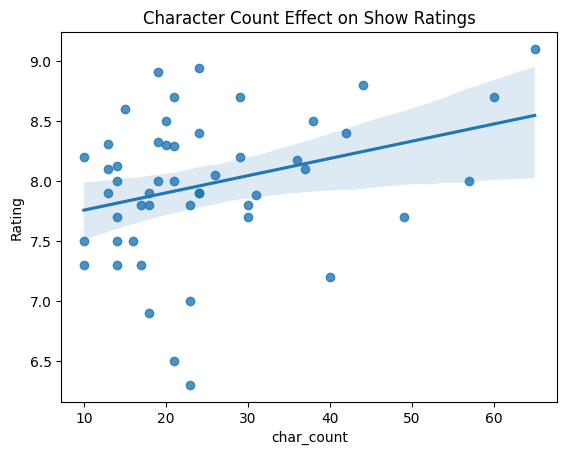

In [ ]:
# Small sample size but looks like more characters = higher rating
sns.regplot(data=chars_and_ratings, x='char_count', y='Rating')
plt.title('Character Count Effect on Show Ratings');
# Wide range of data still, unable to say for certain if character count affects show ratings

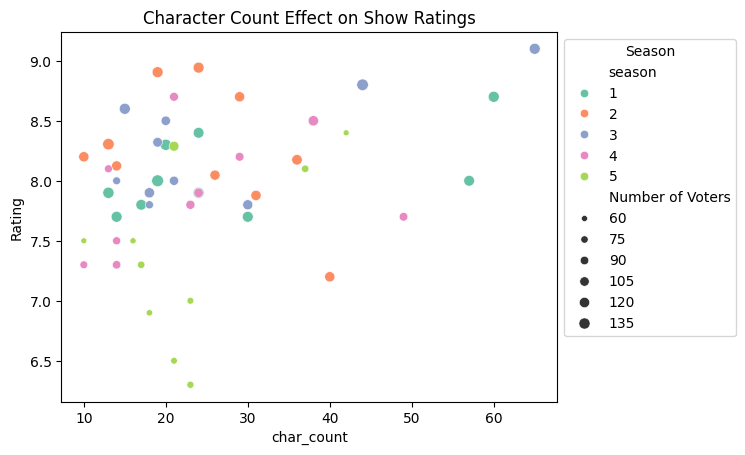

In [ ]:
sns.scatterplot(data=chars_and_ratings, x='char_count', y='Rating', hue = 'season', palette = 'Set2', size = 'Number of Voters');
plt.title('Character Count Effect on Show Ratings'); plt.legend(
title='Season', bbox_to_anchor=(1, 1), loc='upper left')

plt.show()

# margin of error
# it seems that season 5 has the lowest ratings regardless of character count, but also has the lowest number of voters which could affect the average
# Episode 1 had incongruous amount of voters compared to the rest of the episodes
# In terms of number of voters, viewers probably more motivated to vote in the first place if they really enjoyed the episode

**Tests for Rick and Morty API**

In [ ]:
url = 'https://rickandmortyapi.com/api/episode/50'
while url:
  response = requests.get(url)
  if response.status_code != 200:
    print(f"Error: {response.status_code}")
    break
  data = response.json()
print(data)

# checks number of characters in a single episode, chose episode 50, since it has a low character count, to confirm

Error: 429
{'id': 50, 'name': 'Forgetting Sarick Mortshall', 'air_date': 'September 5, 2021', 'episode': 'S05E09', 'characters': ['https://rickandmortyapi.com/api/character/1', 'https://rickandmortyapi.com/api/character/2', 'https://rickandmortyapi.com/api/character/5', 'https://rickandmortyapi.com/api/character/787', 'https://rickandmortyapi.com/api/character/788', 'https://rickandmortyapi.com/api/character/789', 'https://rickandmortyapi.com/api/character/790', 'https://rickandmortyapi.com/api/character/791', 'https://rickandmortyapi.com/api/character/792', 'https://rickandmortyapi.com/api/character/793'], 'url': 'https://rickandmortyapi.com/api/episode/50', 'created': '2021-10-15T17:00:24.105Z'}


In [ ]:
url = 'https://rickandmortyapi.com/api/character/329'
while url:
  response = requests.get(url)
  if response.status_code != 200:
    print(f"Error: {response.status_code}")
    break
  data = response.json()
print(data)

# checks number of episodes a character appears in, chose character 329, since chart says only 8 appearances, to confirm

Error: 429
{'id': 50, 'name': 'Forgetting Sarick Mortshall', 'air_date': 'September 5, 2021', 'episode': 'S05E09', 'characters': ['https://rickandmortyapi.com/api/character/1', 'https://rickandmortyapi.com/api/character/2', 'https://rickandmortyapi.com/api/character/5', 'https://rickandmortyapi.com/api/character/787', 'https://rickandmortyapi.com/api/character/788', 'https://rickandmortyapi.com/api/character/789', 'https://rickandmortyapi.com/api/character/790', 'https://rickandmortyapi.com/api/character/791', 'https://rickandmortyapi.com/api/character/792', 'https://rickandmortyapi.com/api/character/793'], 'url': 'https://rickandmortyapi.com/api/episode/50', 'created': '2021-10-15T17:00:24.105Z'}


In [ ]:
import requests
import time

characters = []
url = 'https://rickandmortyapi.com/api/character'

while url:
  response = requests.get(url)
  if response.status_code != 200:
    print(f"Error: {response.status_code}")
    break
  data = response.json()
  characters.extend(data['results'])
  url = data['info']['next']
  time.sleep(2)
char_stats = pd.DataFrame(characters)
# Making new column in existing DF, setting it equal to number of episodes that each character appears in
char_stats['episode_count'] = char_stats['episode'].str.len()

In [ ]:
records = []

for char in characters:
    ep_list = []

    # for each url in character episodes list, find the episode number by taking the part of the string after the last '/' in the url
    for ep_url in char['episode']:
        # adding the episode number to ep_list
        ep_list.append(int(ep_url.split('/')[-1]))

    ep_list = sorted(ep_list)
    appearance_number = 0

    # still inside character loop, looking at each number in the list of numbers (ep_list)
    for ep_num in ep_list:
        # for each episode, it's adding 1 to the appearance number
        appearance_number = appearance_number + 1
        # creating multiple dicts within a record per episode... for every episode, it's creating a record ... in display(df_rates): each row is a record
        record = {
            'name': char['name'],
            'ep_num': ep_num,
            'appearance_number': appearance_number
        }
        records.append(record)

#creates a new DF for the records
df_rates = pd.DataFrame(records)


# average appearance number across all characters per episode

# taking all the records from df_rates and grouping them by the episode number, for each ep number it's looking at the appearance number and taking the mean of the appearance number
# avg_age is the average age of all the characters in each episode
# the higher the average = the more common characters, the lower the average = newer characters
# newer characters bring down the average since they're appearance number is low
avg_age = df_rates.groupby('ep_num')['appearance_number'].mean().reset_index()
# renames the columns after it's calculated the average appearance number of all the characters for all of the episodes
avg_age.columns = ['ep_num', 'avg_appearance_number']

    ep_num  avg_appearance_number
0        1               1.000000
1        2               1.315789
2        3               1.416667
3        4               2.461538
4        5               2.050000
5        6               2.583333
6        7               2.142857
7        8               1.368421
8        9               2.588235
9       10               1.627119
10      11               2.833333
11      12               4.076923
12      13               2.166667
13      14               4.571429
14      15               3.375000
15      16               3.290323
16      17               4.105263
17      18               4.037037
18      19               3.050000
19      20               8.600000
20      21               4.766667
21      22               3.909091
22      23               6.055556
23      24               7.200000
24      25               5.133333
25      26               6.571429
26      27               7.157895
27      28               2.400000
28      29    

**Tests for average age**

In [ ]:
# This checks the episode number and appearance number of a specific character
print(df_rates[df_rates['name'] == 'Mr. Poopybutthole'].head(10))

# For the group by function: all the ppl that appear in episode 10
display(df_rates[df_rates['ep_num'] == 10])

# This checks / confirms the info from the episode_lists / ep_numbers in char_stats dF
rick = char_stats[char_stats['id'] == 240].iloc[0]
print(rick['episode'])

# This prints the average age of all the characters for each episode
print(avg_age)

                  name  ep_num  appearance_number
580  Mr. Poopybutthole      15                  1
581  Mr. Poopybutthole      21                  2
582  Mr. Poopybutthole      29                  3
583  Mr. Poopybutthole      30                  4
584  Mr. Poopybutthole      31                  5
585  Mr. Poopybutthole      34                  6
586  Mr. Poopybutthole      51                  7


,name,ep_num,appearance_number
9,Rick Sanchez,10,10
60,Morty Smith,10,10
106,Summer Smith,10,5
148,Beth Smith,10,5
190,Jerry Smith,10,5
226,Abradolf Lincler,10,1
234,Alien Morty,10,1
235,Alien Rick,10,1
238,Antenna Morty,10,1
240,Antenna Rick,10,1


['https://rickandmortyapi.com/api/episode/9', 'https://rickandmortyapi.com/api/episode/16', 'https://rickandmortyapi.com/api/episode/17', 'https://rickandmortyapi.com/api/episode/18', 'https://rickandmortyapi.com/api/episode/21', 'https://rickandmortyapi.com/api/episode/22', 'https://rickandmortyapi.com/api/episode/24', 'https://rickandmortyapi.com/api/episode/27', 'https://rickandmortyapi.com/api/episode/30', 'https://rickandmortyapi.com/api/episode/39']
    ep_num  avg_appearance_number
0        1               1.000000
1        2               1.315789
2        3               1.416667
3        4               2.461538
4        5               2.050000
5        6               2.583333
6        7               2.142857
7        8               1.368421
8        9               2.588235
9       10               1.627119
10      11               2.833333
11      12               4.076923
12      13               2.166667
13      14               4.571429
14      15               3.375

In [ ]:

avg_age
ratings

age_and_ratings = avg_age.merge(ratings, left_on='ep_num', right_on='ID', how='inner')
display(age_and_ratings)

,ep_num,avg_appearance_number,Episode,ID,Episode Number,Season Number,Rating,Number of Voters
0,2,1.315789,LAWNMOWER DOG,2,2,1,8.000,149
1,3,1.416667,ANATOMY PARK,3,3,1,7.900,133
2,4,2.461538,M. NIGHT SHAYM-ALIENS!,4,4,1,7.900,137
3,5,2.050000,MEESEEKS AND DESTROY,5,5,1,8.300,136
4,6,2.583333,RICK POTION #9,6,6,1,8.400,128
5,7,2.142857,RAISING GAZORPAZORP,7,7,1,7.700,131
6,8,1.368421,RIXTY MINUTES,8,8,1,8.000,128
7,9,2.588235,SOMETHING RICKED THIS WAY COMES,9,9,1,7.800,127
8,10,1.627119,CLOSE RICK-COUNTERS OF THE RICK KIND,10,10,1,8.700,133
9,11,2.833333,RICKSY BUSINESS,11,11,1,7.700,130


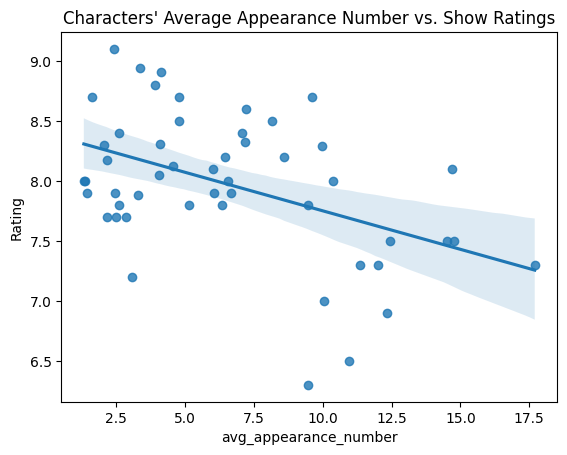

In [ ]:
sns.regplot(data=age_and_ratings, x='avg_appearance_number', y='Rating')
plt.title("Characters' Average Appearance Number vs. Show Ratings");

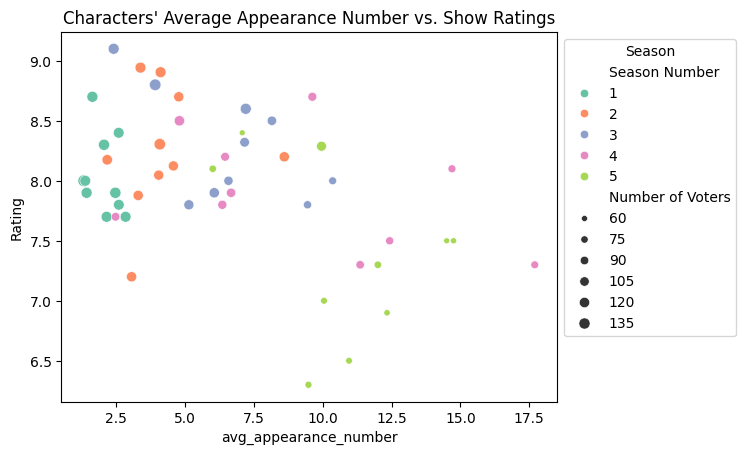

In [ ]:
sns.scatterplot(data=age_and_ratings, x='avg_appearance_number', y='Rating', hue = 'Season Number', palette = 'Set2', size = 'Number of Voters');
plt.title("Characters' Average Appearance Number vs. Show Ratings"); plt.legend(
title='Season', bbox_to_anchor=(1, 1), loc='upper left')

plt.show()